The purpose of this code is to plot our data onto a scatterplot. It adds performance targets we can change and add to the graph. Then it formats and graphs six graphs for different grade bands and for district vs school level.

In [1]:
import pandas as pd
import numpy as np
import os, csv, re
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path
from matplotlib.ticker import PercentFormatter
from adjustText import adjust_text
plt.close("all")
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', '{:.0f}'.format) # Turn off scientific notation
pd.set_option('display.float_format', '{:.2f}'.format) # Force display floats with 2 decimal globally

def format_headers(df):
    df.columns = (
        df.columns.astype(str)
        .str.replace(r"[./ >#:?*\-]", "_", regex=True)
        .str.replace(r"[()']", "", regex=True)
        .str.replace("%", "", regex=False)
        .str.replace(",", "", regex=False)
        .str.lower()
        .str.replace(r"_+", "_", regex=True)
        .str.strip()
        .str.strip("_")
    )
    return df


from decimal import Decimal, ROUND_HALF_UP

In [2]:
# Selects which data set we want to analyse

subject = "math"
# subject = "reading"
subject_title = subject.title()
subject_title

'Math'

In [3]:
# Creates a folder named graphs

output_dir = Path("graphs")
output_dir.mkdir(parents=True, exist_ok=True)

In [4]:
# Imports the table

table = pd.read_csv(f"intermediate/01_CleanTest_{subject}.csv")
table.columns

Index(['school', 'student_grade', 'met_growth_count', 'met_growth_percent',
       'met_growth_sum', 'met_performance_count', 'met_performance_percent',
       'met_performance_sum'],
      dtype='str')

In [5]:
# Value count. Checks for unwanted grades.

table["student_grade"].value_counts(dropna=False)

student_grade
1    17
2    17
3    17
4    17
5    17
6    17
7    17
8    17
K    17
Name: count, dtype: int64

In [6]:
# Categorises the grades so K can be in front

grade_order = ["K", "1", "2", "3", "4", "5", "6", "7", "8"]

table["student_grade"] = pd.Categorical(
    table["student_grade"].astype(str),
    categories=grade_order,
    ordered=True)
table = table.sort_values("student_grade")

In [7]:
# Creates school_grade column which has school + grade

table["school_abrv"] = table["school"].apply(
    lambda x: "".join(word[0] for word in x.split())
)
table["school_grade"] = (
    table["school_abrv"] + " " + table["student_grade"].astype(str)
)

In [8]:
# Used dictionarys to create the performance goals

if subject_title == "Reading":
    target_dict = {
        "K":0.63,
        "1":0.66,
        "2":0.64,
        "3":0.56,
        "4":0.58,
        "5":0.55,
        "6":0.57,
        "7":0.54,
        "8":0.56
    }

elif subject_title == "Math":
    target_dict = {
        "K":0.60,
        "1":0.62,
        "2":0.61,
        "3":0.53,
        "4":0.55,
        "5":0.52,
        "6":0.54,
        "7":0.51,
        "8":0.53
    }





In [9]:
# In this large block of code I created a function to structure my graph. Such as creating different lines for performance goals and if some -
# performance goals overlapped they would be different. It sets the grid style axis names and title as well as the axis limits. Percent format.

def structure():
    ax.yaxis.set_major_locator(ticker.MultipleLocator(0.1))
    ax.xaxis.set_major_locator(ticker.MultipleLocator(0.1))
    ax.grid(True)
    ax.xaxis.set_major_formatter(PercentFormatter(1))
    ax.yaxis.set_major_formatter(PercentFormatter(1))
    ax.axhline(1, linestyle="dotted", alpha=0.7, color="black")
    ax.text(0.77,0.97,"EOY Growth Target", alpha=0.7, fontsize=10)

    if target_dict[grades[0]] == target_dict[grades[1]] == target_dict[grades[2]]:
        ax.text(target_dict[grades[0]] -0.02,0.7,f"EOY Performance Target {grades[0]} & {grades[1]} & {grades[2]}", zorder=1, alpha=0.7, fontsize=10, rotation = 90, color = "black")
        ax.axvline(target_dict[grades[0]], zorder=1, alpha=0.7, linestyle="dotted", color="black")
    elif target_dict[grades[0]] == target_dict[grades[1]]:
        ax.text(target_dict[grades[0]] -0.02,0.7,f"EOY Performance Target {grades[0]} & {grades[1]}", zorder=1, alpha=0.7, fontsize=10, rotation = 90, color = "black")
        ax.text(target_dict[grades[2]] -0.02,0.7,f"EOY Performance Target {grades[2]}", zorder=1, alpha=0.7, fontsize=10, rotation = 90, color = "blue")
        ax.axvline(target_dict[grades[0]], zorder=1, alpha=0.7, linestyle="dotted", color="black")
        ax.axvline(target_dict[grades[2]], zorder=1, alpha=0.7, linestyle="dotted", color="blue")
    elif target_dict[grades[2]] == target_dict[grades[1]]:
        ax.text(target_dict[grades[2]] -0.02,0.7,f"EOY Performance Target {grades[1]} & {grades[2]}", zorder=1, alpha=0.7, fontsize=10, rotation = 90, color = "black")
        ax.text(target_dict[grades[0]] -0.02,0.7,f"EOY Performance Target {grades[0]}", zorder=1, alpha=0.7, fontsize=10, rotation = 90, color = "green")
        ax.axvline(target_dict[grades[2]], zorder=1, alpha=0.7, linestyle="dotted", color="black")
        ax.axvline(target_dict[grades[0]], zorder=1, alpha=0.7, linestyle="dotted", color="green")
    elif target_dict[grades[2]] == target_dict[grades[0]]:
        ax.text(target_dict[grades[2]] -0.02,0.7,f"EOY Performance Target {grades[0]} & {grades[2]}", zorder=1, alpha=0.7, fontsize=10, rotation = 90, color = "black")
        ax.text(target_dict[grades[1]] -0.02,0.7,f"EOY Performance Target {grades[1]}", zorder=1, alpha=0.7, fontsize=10, rotation = 90, color = "purple")
        ax.axvline(target_dict[grades[1]], zorder=1, alpha=0.7, linestyle="dotted", color="purple")
        ax.axvline(target_dict[grades[0]], zorder=1, alpha=0.7, linestyle="dotted", color="black")
    else:
        ax.text(target_dict[grades[0]] -0.02,0.7,f"EOY Performance Target {grades[0]}", zorder=1, alpha=0.7, fontsize=10, rotation = 90, color = "green")
        ax.text(target_dict[grades[1]] -0.02,0.7,f"EOY Performance Target {grades[1]}", zorder=1, alpha=0.7, fontsize=10, rotation = 90, color = "purple")
        ax.text(target_dict[grades[2]] -0.02,0.7,f"EOY Performance Target {grades[2]}", zorder=1, alpha=0.7, fontsize=10, rotation = 90, color = "blue")
        ax.axvline(target_dict[grades[0]], zorder=1, alpha=0.7, linestyle="dotted", color="green")
        ax.axvline(target_dict[grades[1]], zorder=1, alpha=0.7, linestyle="dotted", color="purple")
        ax.axvline(target_dict[grades[2]], zorder=1, alpha=0.7, linestyle="dotted", color="blue")

    

    ax.set_xlabel("% of Students That Met Grade Level Performance", fontsize=14)
    ax.set_ylabel("% of Students That Met 100% Annual Typical Growth", fontsize=14)

    ax.set_title(
        f"Summit Valley School District: 2025-2026 EOY Test {subject_title}\n"
        f"Percent of Students Grades {band_name} Meeting Performance and Growth Targets", fontsize=14
    )

    ax.set_xlim(0, 1.01)
    ax.set_ylim(0, 1.01)


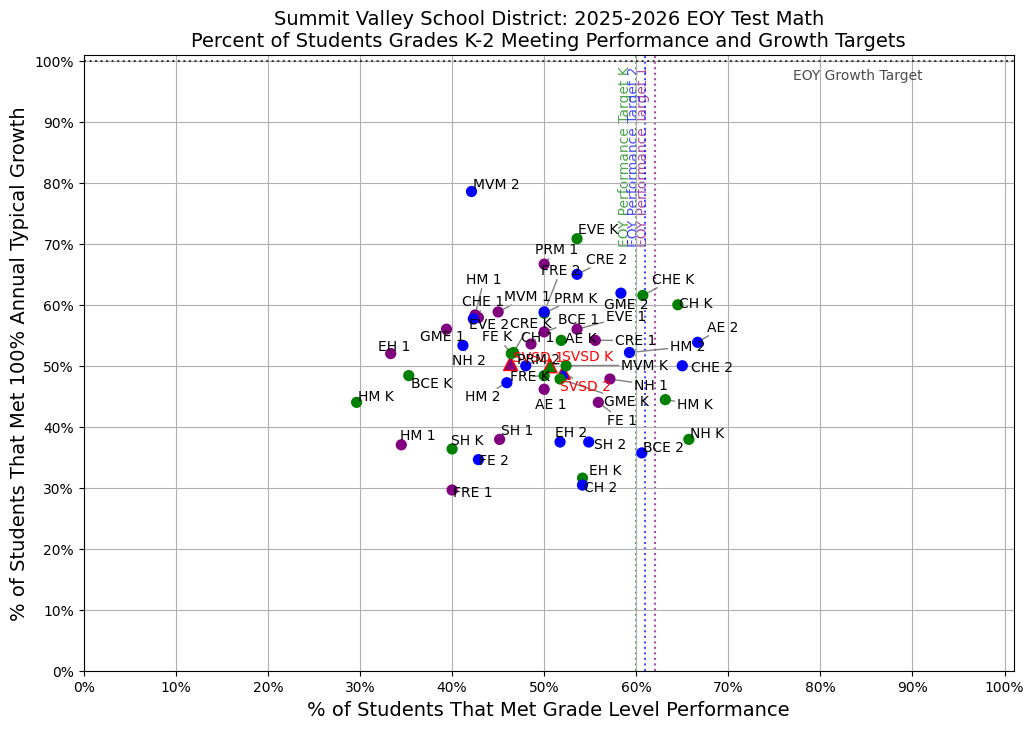

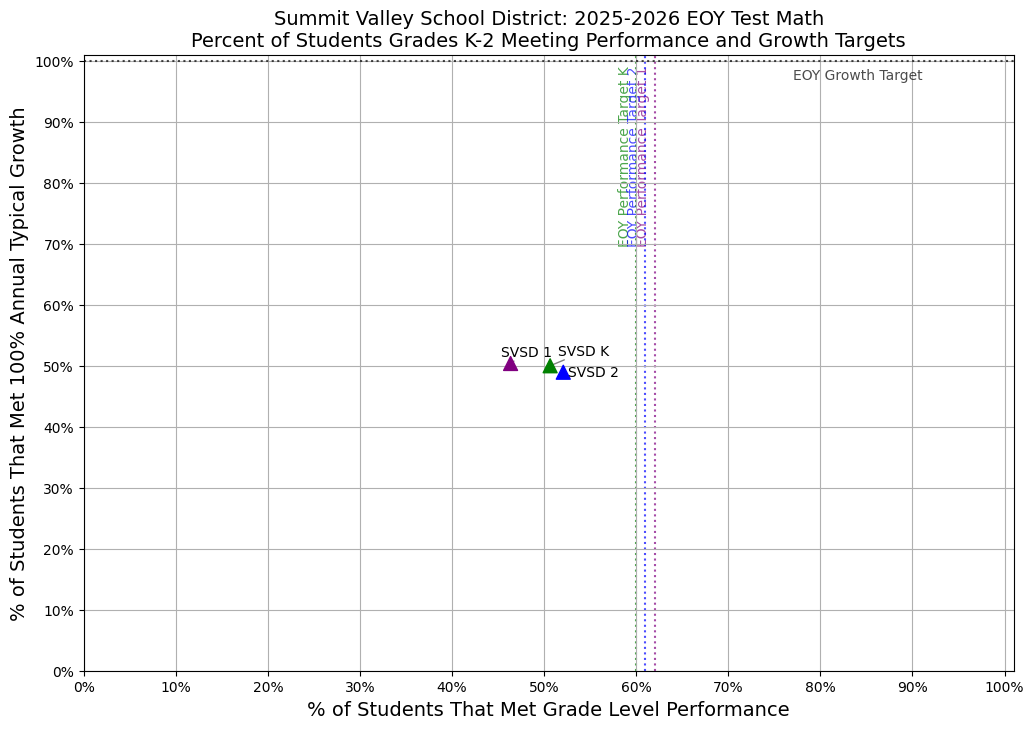

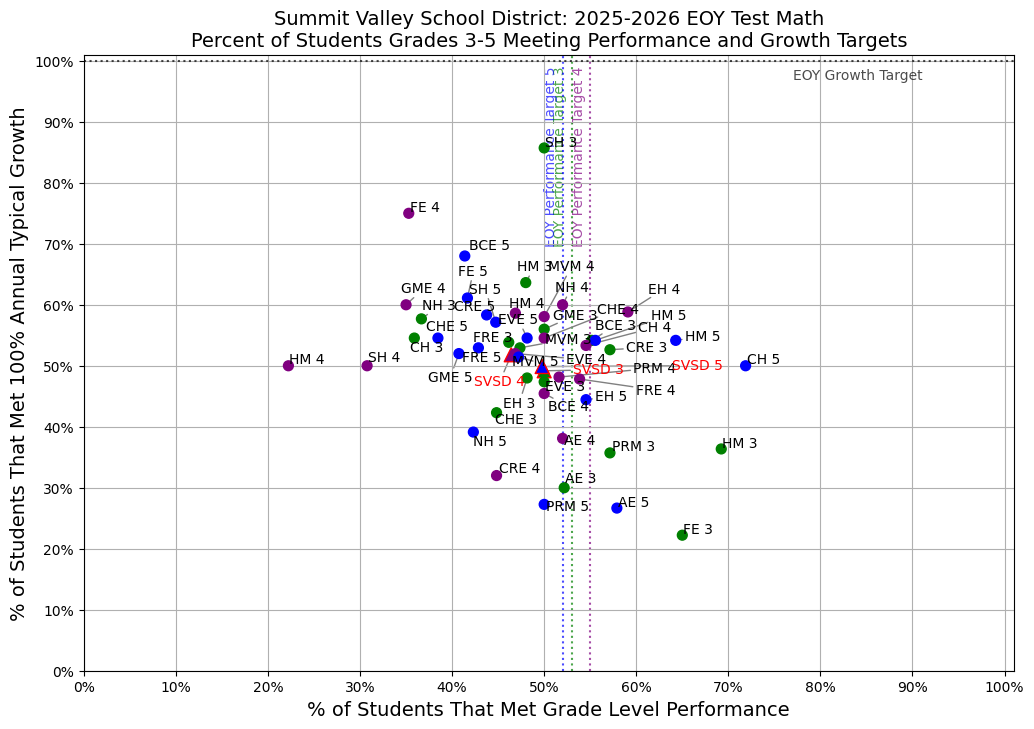

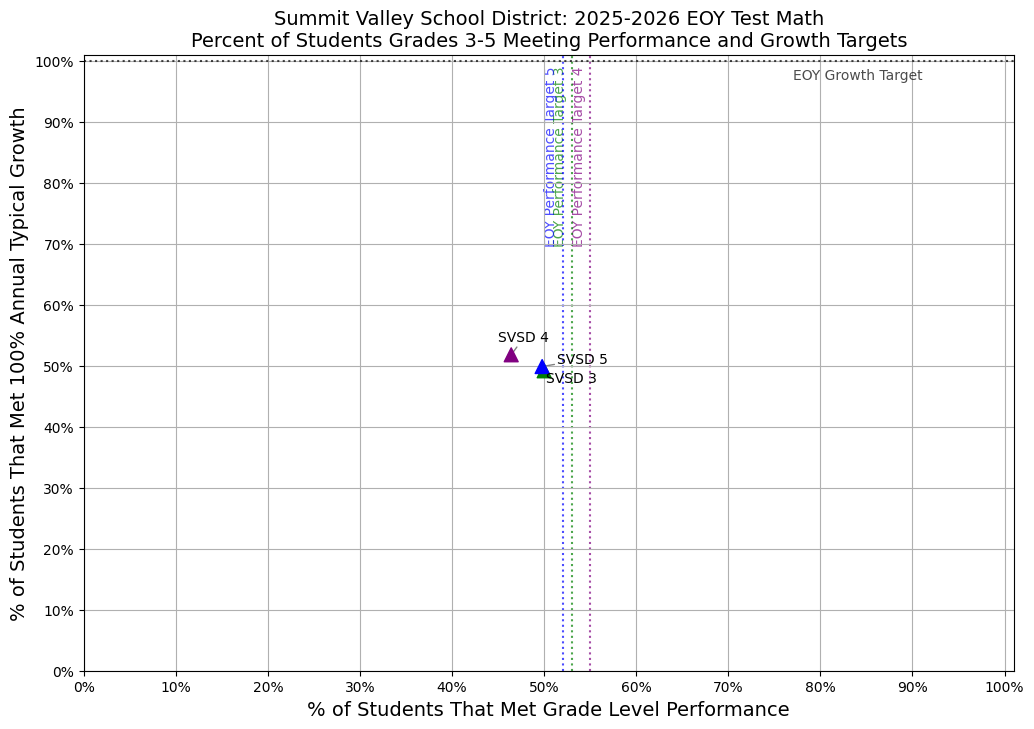

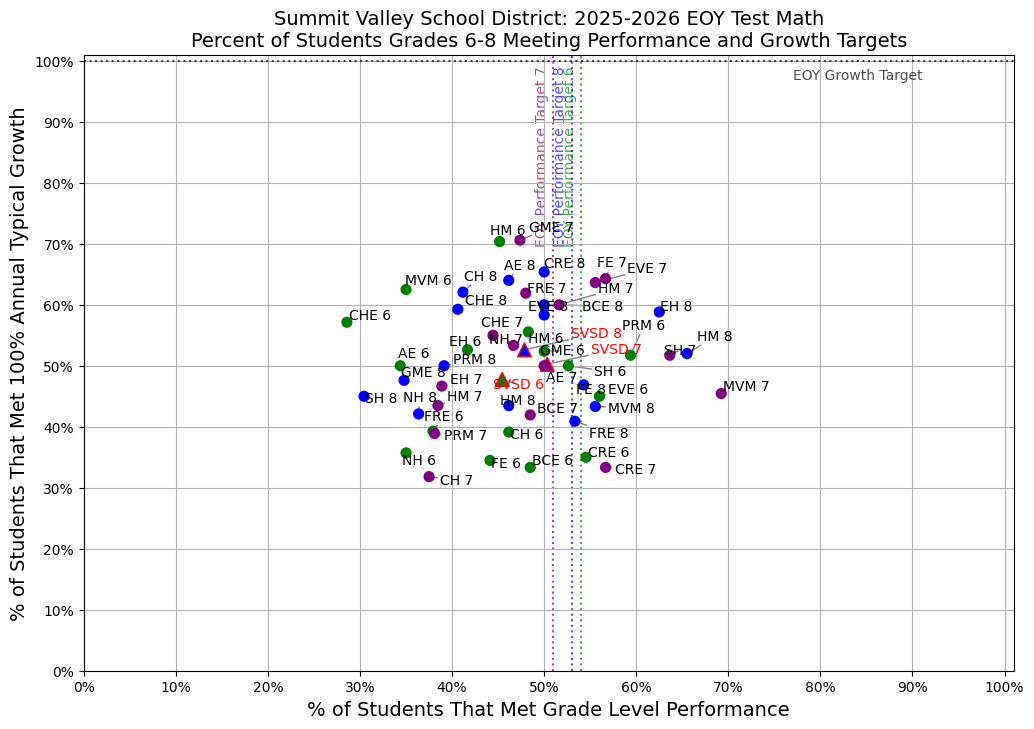

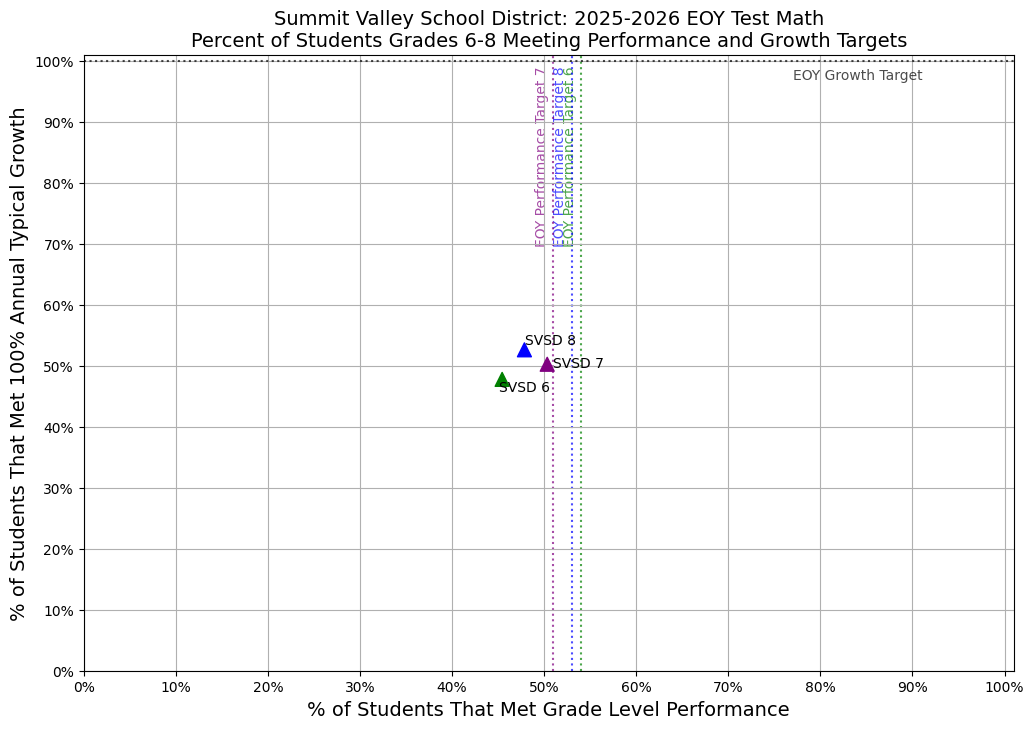

In [10]:
# Creates the graphs. First, created a dictionary for grade bands. Created a loop that makes graphs for each grade band. Each loop creates a graph -
# for the overall district and then the district + schools. Sets different colors and shapes for the data. Added labels for the data that do not -
# overlap and have lines connecting data to the labels.

grade_bands = {
    "K-2": ["K", "1", "2"],
    "3-5": ["3", "4", "5"],
    "6-8": ["6", "7", "8"]
}

for band_name, grades in grade_bands.items():

    band_df = table[table["student_grade"].astype(str).isin(grades)]
    svsd = band_df[band_df["school"] == "Summit Valley School District"]
    other = band_df[band_df["school"] != "Summit Valley School District"]
    
    fig, ax = plt.subplots(figsize=(12, 8))

    colors_dict = {
        grades[0] : "green",
        grades[1] : "purple",
        grades[2] : "blue"
    }

# Creates the graphs
    color = svsd["student_grade"].astype(str).map(colors_dict)
    colors = other["student_grade"].astype(str).map(colors_dict)
    svsd.plot.scatter(
        "met_performance_percent",
        "met_growth_percent", zorder=2, marker = "^", edgecolors = "red",
        s=100,
        c=color,
        ax=ax
    )

    other.plot.scatter(
        "met_performance_percent",
        "met_growth_percent", zorder=2, marker = "o",
        s=50,
        c=colors,
        ax=ax
    )

    structure()

# Overall text without overlapping
    texts = []
    for _, row in band_df.iterrows():
        colored = "red" if row["school"] == "Summit Valley School District" else "black"
        texts.append(
            ax.annotate(
                row["school_grade"],
                (row["met_performance_percent"],
                 row["met_growth_percent"]), c=colored,
                fontsize=10
            )
        )
    adjust_text(
        texts,
        arrowprops=dict(
            arrowstyle="-",
            color="gray"
        )
    )

# Puts graph in my file
    output_dir = Path(f"graphs/{subject}")
    output_dir.mkdir(parents=True, exist_ok=True)
    file_path = output_dir / f"{band_name}_{subject}_2026.png"
    plt.savefig(file_path, bbox_inches='tight')

    plt.show()

# District graph
    fig, ax = plt.subplots(figsize=(12, 8))
    svsd.plot.scatter(
        "met_performance_percent",
        "met_growth_percent", zorder=2, marker = "^",
        s=100,
        c=color,
        ax=ax
    )

    structure()

# District labels
    texts = []
    for _, row in svsd.iterrows():
        texts.append(
            ax.annotate(
                row["school_grade"],
                (row["met_performance_percent"],
                 row["met_growth_percent"]), zorder=2,
                fontsize=10
            )
        )
    adjust_text(
        texts,
        arrowprops=dict(
            arrowstyle="-",
            color="gray"
        )
    )
    
    file_path = output_dir / f"{band_name}_SVSD_{subject}_2026.png"
    plt.savefig(file_path, bbox_inches='tight')
    